# Experiment No 8

**Aim:** To implement K-Means and Hierarchical Clustering algorithms to identify patterns in unlabelled data.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from ucimlrepo import fetch_ucirepo

### K-Means Clustering on Synthetic Blob Data

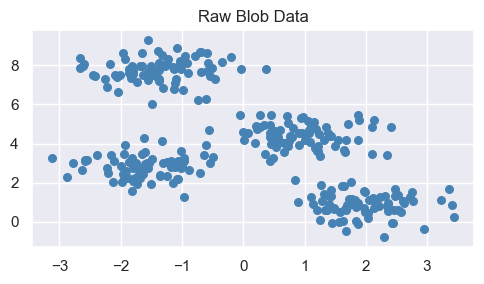

In [8]:
X_blob, y_blob = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.figure(figsize=(5, 3))
plt.scatter(X_blob[:, 0], X_blob[:, 1], s=30, color='steelblue')
plt.title('Raw Blob Data')
plt.tight_layout(); plt.show()

### Fit K-Means and Visualise Clusters

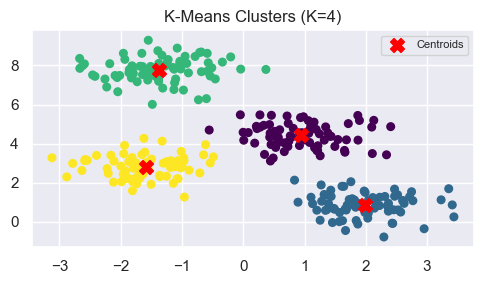

In [9]:
kmeans_blob = KMeans(n_clusters=4, random_state=0, n_init=10)
y_kmeans = kmeans_blob.fit_predict(X_blob)

plt.figure(figsize=(5, 3))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_kmeans, s=30, cmap='viridis')
plt.scatter(kmeans_blob.cluster_centers_[:, 0], kmeans_blob.cluster_centers_[:, 1],
            c='red', s=100, marker='X', label='Centroids')
plt.title('K-Means Clusters (K=4)')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Choosing K – Elbow Method

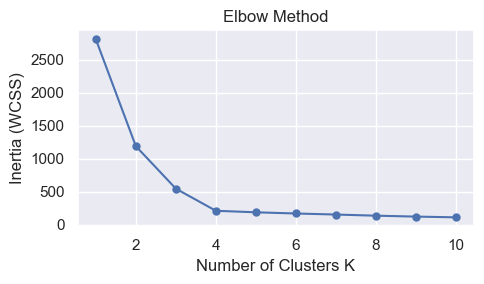

In [10]:
inertias = [KMeans(n_clusters=k, random_state=0, n_init=10).fit(X_blob).inertia_
            for k in range(1, 11)]

plt.figure(figsize=(5, 3))
plt.plot(range(1, 11), inertias, marker='o', markersize=5)
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.tight_layout(); plt.show()

### Limitations of K-Means

K-Means assumes clusters are **convex and roughly equal in size**. It struggles with non-circular or irregularly shaped clusters, as shown below.

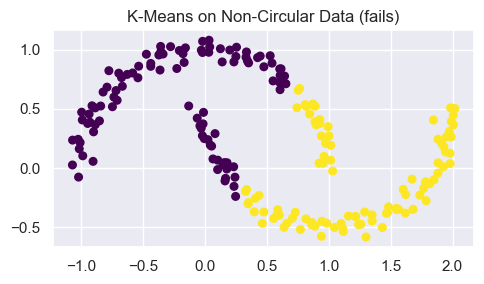

In [11]:
X_moon, _ = make_moons(200, noise=0.05, random_state=0)
labels_moon = KMeans(2, random_state=0, n_init=10).fit_predict(X_moon)

plt.figure(figsize=(5, 3))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_moon, s=30, cmap='viridis')
plt.title('K-Means on Non-Circular Data (fails)')
plt.tight_layout(); plt.show()

### Hierarchical Clustering on Synthetic Blob Data

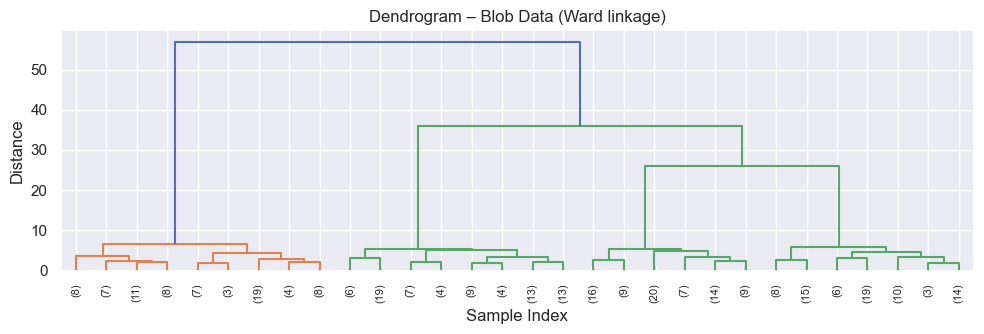

In [12]:
Z_blob = linkage(X_blob, method='ward')

plt.figure(figsize=(10, 3.5))
dendrogram(Z_blob, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
plt.title('Dendrogram – Blob Data (Ward linkage)')
plt.xlabel('Sample Index'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()

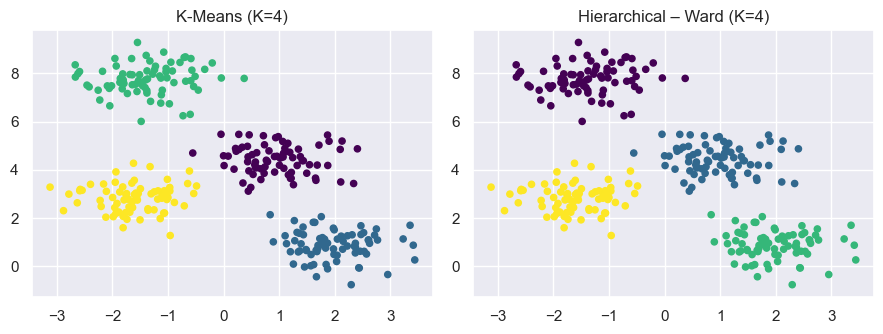

In [13]:
agg_blob = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_agg_blob = agg_blob.fit_predict(X_blob)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, labels, title in zip(axes,
    [y_kmeans, y_agg_blob],
    ['K-Means (K=4)', 'Hierarchical – Ward (K=4)']):
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, s=20, cmap='viridis')
    ax.set_title(title)
plt.tight_layout(); plt.show()

### Application to Spambase Dataset

In [14]:
spambase = fetch_ucirepo(id=94)
df = pd.concat([spambase.data.features, spambase.data.targets], axis=1)
X_spam = df.drop(columns=['Class'])
y_true = df['Class'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spam)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Variance explained by 2 PCs: 17.30%


### K-Means on Spambase (K=2)

,Silhouette Score,Adjusted Rand Index
0,0.6596,-0.0049


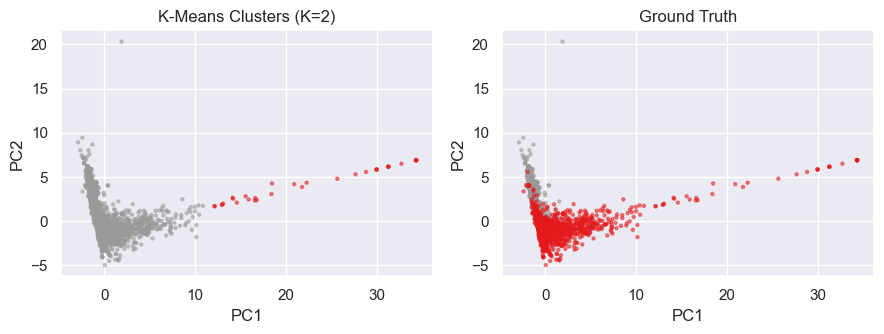

In [15]:
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km2.fit_predict(X_scaled)

display(pd.DataFrame({
    'Silhouette Score':    [silhouette_score(X_scaled, km_labels)],
    'Adjusted Rand Index': [adjusted_rand_score(y_true, km_labels)]
}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, labels, title in zip(axes,
    [km_labels, y_true],
    ['K-Means Clusters (K=2)', 'Ground Truth']):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', s=5, alpha=0.5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
plt.tight_layout(); plt.show()

### Hierarchical Clustering on Spambase (K=2)

,Silhouette Score,Adjusted Rand Index
0,0.666,-0.0048


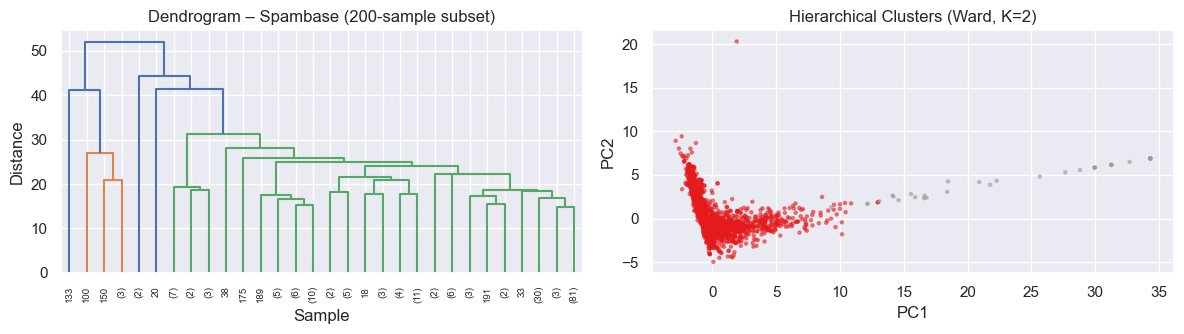

In [16]:
sample_idx = np.random.RandomState(42).choice(len(X_scaled), 200, replace=False)
Z_spam = linkage(X_scaled[sample_idx], method='ward')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

dendrogram(Z_spam, ax=axes[0], truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=7, show_contracted=True)
axes[0].set_title('Dendrogram – Spambase (200-sample subset)')
axes[0].set_xlabel('Sample'); axes[0].set_ylabel('Distance')

agg2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg2.fit_predict(X_scaled)

display(pd.DataFrame({
    'Silhouette Score':    [silhouette_score(X_scaled, agg_labels)],
    'Adjusted Rand Index': [adjusted_rand_score(y_true, agg_labels)]
}).round(4))

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='Set1', s=5, alpha=0.5)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('Hierarchical Clusters (Ward, K=2)')

plt.tight_layout(); plt.show()

## Conclusion

K-Means works well on compact, convex clusters but fails on non-circular shapes like moons. Hierarchical clustering with Ward linkage offers a richer view via the dendrogram. On Spambase, both methods recover clusters broadly aligned with spam/non-spam labels, confirmed by the Adjusted Rand Index.